In [104]:
from networkx.readwrite import json_graph
import json
import re
from collections import defaultdict
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import math
from collections import Counter

In [105]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/andreasstampedalgaard/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [121]:
stop_words.update({
    "wthn", "rfa", "wp", "afd", "rfbs", "talk",
    "page", "edit", "editing", "edits"
})

In [122]:
with open("rfa_graph.json", "r", encoding="utf-8") as f:
    data = json.load(f)

G = json_graph.node_link_graph(data)

In [123]:
texts = defaultdict(list)

for u, v, d in G.edges(data=True):
    vote = d.get("vote")
    text = d.get("text", "")
    
    if text:
        texts[vote].append(text)

print("Positive:", len(texts[1]))
print("Negative:", len(texts[-1]))
print("Neutral:", len(texts[0]))

Positive: 138715
Negative: 40435
Neutral: 11935


In [124]:
import re

def clean_wiki_text(text):
    text = text.lower()

    # remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # remove wiki formatting
    text = re.sub(r"'+", "", text)

    # handle wiki links [[A|B]] → B
    text = re.sub(r"\[\[[^|\]]*\|([^\]]+)\]\]", r"\1", text)
    text = re.sub(r"\[\[([^\]]+)\]\]", r"\1", text)

    # remove URLs
    text = re.sub(r"http\S+", "", text)

    # remove non-letters
    text = re.sub(r"[^a-z\s]", " ", text)

    # remove user mentions
    text = re.sub(r"user:\w+", "", text)

    # split into words
    words = text.split()

    # remove all-uppercase words (often acronyms or noise)
    words = [w for w in words if not w.isupper()]

    # 🚨 THIS is where stopwords are actually applied
    words = [w for w in words if w not in stop_words]

    return " ".join(words)

In [125]:
positive_text = clean_wiki_text(" ".join(texts[1]))
negative_text = clean_wiki_text(" ".join(texts[-1]))
neutral_text  = clean_wiki_text(" ".join(texts[0]))

In [126]:
documents = {
    "positive": positive_text.split(),
    "negative": negative_text.split(),
    "neutral": neutral_text.split()
}

In [127]:
for label, words in documents.items():
    print(label, len(words))

positive 1464997
negative 918095
neutral 282847


In [128]:
def compute_tf(words):
    counts = Counter(words)
    total_terms = len(words)
    
    tf = {}
    for word, count in counts.items():
        tf[word] = count / total_terms
    
    return tf

In [129]:
tf_scores = {}

for label, words in documents.items():
    tf_scores[label] = compute_tf(words)

In [130]:
def compute_df(documents):
    df = Counter()
    
    for words in documents.values():
        unique_words = set(words)
        for word in unique_words:
            df[word] += 1
    
    return df

df_scores = compute_df(documents)

In [131]:
N = len(documents)

idf_scores = {}

for word, df in df_scores.items():
    idf_scores[word] = math.log(N / df)

In [132]:
tfidf_scores = {}

for label in documents:
    tfidf_scores[label] = {}
    for word, tf in tf_scores[label].items():
        tfidf_scores[label][word] = tf * idf_scores[word]

In [133]:
def top_tfidf_words(tfidf_dict, n=5):
    return sorted(tfidf_dict.items(), key=lambda x: x[1], reverse=True)[:n]

for label in tfidf_scores:
    print(f"\nTop TF-IDF words for {label}:")
    for word, score in top_tfidf_words(tfidf_scores[label], n=5):
        print(f"{word}: {score:.6f}")


Top TF-IDF words for positive:
deo: 0.000119
overdue: 0.000091
volente: 0.000062
juvente: 0.000057
yup: 0.000055

Top TF-IDF words for negative:
opposeper: 0.000020
rushed: 0.000018
accuses: 0.000018
captandum: 0.000017
aave: 0.000017

Top TF-IDF words for neutral:
neutrali: 0.000019
sega: 0.000019
weirdo: 0.000019
lands: 0.000016
ohnoitsjamies: 0.000016


In [134]:
def make_tfidf_wordcloud(tfidf_dict, title):
    wc = WordCloud(width=1000, height=500, background_color="white")
    wc.generate_from_frequencies(tfidf_dict)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

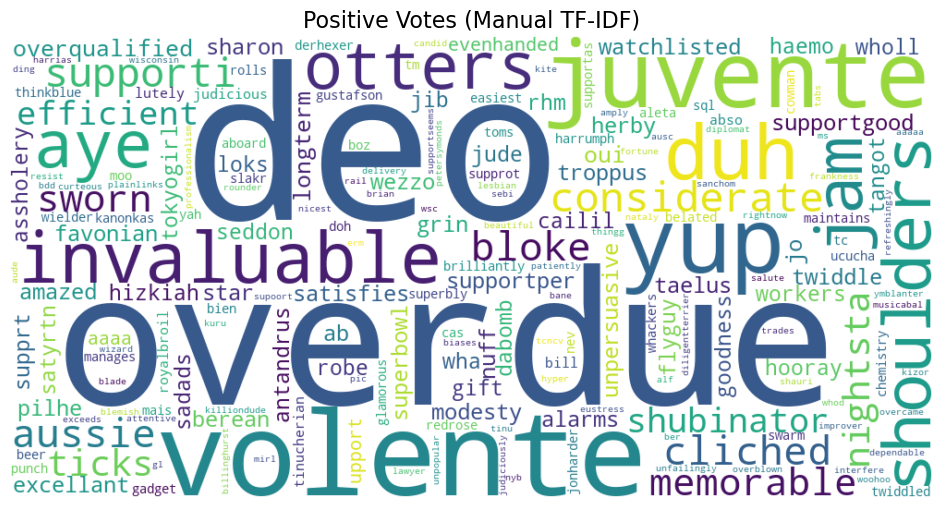

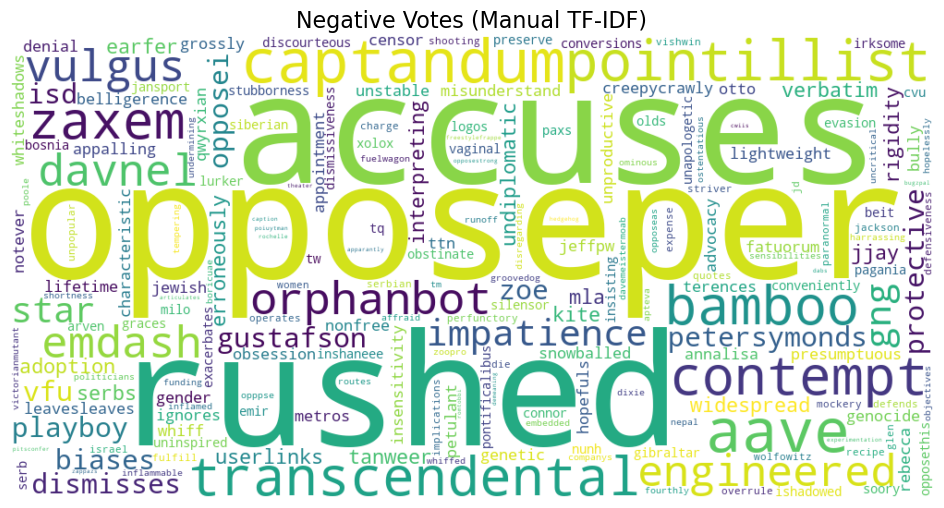

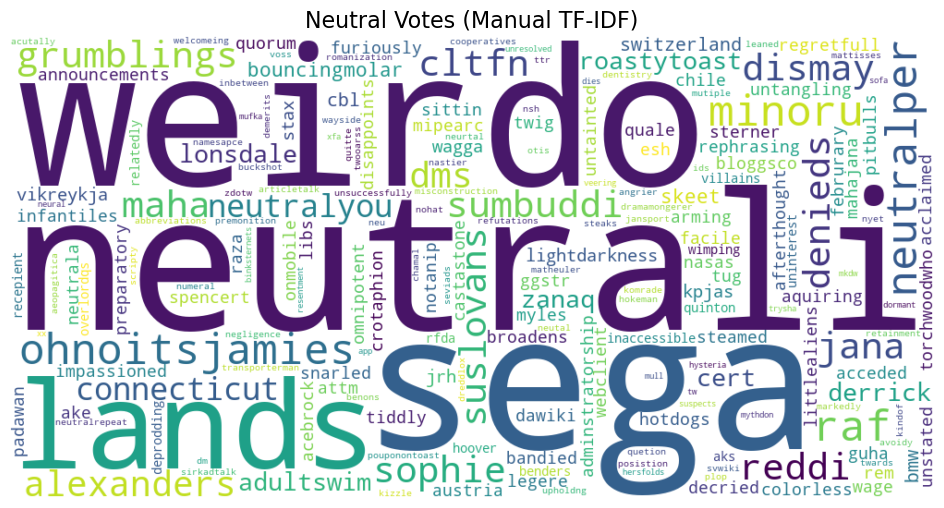

In [135]:
make_tfidf_wordcloud(tfidf_scores["positive"], "Positive Votes (Manual TF-IDF)")
make_tfidf_wordcloud(tfidf_scores["negative"], "Negative Votes (Manual TF-IDF)")
make_tfidf_wordcloud(tfidf_scores["neutral"], "Neutral Votes (Manual TF-IDF)")